### Exploratory Data Analysis

This notebook explores patterns in NYC 311 service request data to better understand the factors that may influence complaint resolution time.

The goal of this analysis is to identify features that may help predict whether a complaint will be **resolved within one week**.

Key objectives of this exploratory analysis include:

• Understanding the distribution of the target variable  
• Examining resolution time behavior  
• Identifying geographic patterns in complaint resolution  
• Exploring relationships between complaint characteristics and response times  
• Detecting data quality issues and outliers  

Insights from this notebook inform feature engineering and modeling decisions in later stages of the project.

#### Import libaries
This section loads the Python libraries required for exploratory data analysis.

Key libraries used:

- **pandas / numpy** for data manipulation
- **matplotlib / seaborn** for visualization
- **scikit-learn utilities** for potential preprocessing support

These tools allow us to explore distributions, identify patterns, and visualize relationships in the NYC 311 dataset.

In [1]:
# Core analysis libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Improve plot styling
sns.set()

# Show all columns during EDA
pd.set_option('display.max_columns', None)

#### Import data
The cleaned dataset generated in the preprocessing notebook is loaded for analysis.

Using the preprocessed dataset ensures that:

• leakage-prone variables have already been removed  
• geographic features are standardized  
• the modeling target variable has been created  

This allows the exploratory analysis to focus on understanding patterns relevant to prediction rather than data cleaning.

In [3]:
# File paths
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
SRC_DIR = PROJECT_ROOT / "src"
DEPLOYMENT_DIR = PROJECT_ROOT / "deployment"

In [4]:
# Save data as parquet file
data = pd.read_parquet(DATA_DIR / "01_nyc_info_preprocessing.parquet")

In [5]:
# Show first five rows of data
data.head(5)

,unique_key,agency,complaint_type,descriptor,incident_zip,borough,latitude,longitude,location_type,resolution_time_days,resolution_in_wk,complaint_hr,complaint_day,complaint_month
0,68336154,DOT,Street Condition,Pothole,11420,queens,40.678150,-73.831082,unknown,0.000000,0,1,0,3
1,68332725,NYPD,Noise - Residential,Banging/Pounding,11104,queens,40.742897,-73.925399,Residential Building/House,0.010498,0,1,0,3
2,68338535,NYPD,Blocked Driveway,Partial Access,11429,queens,40.715043,-73.737347,Street/Sidewalk,0.016169,0,1,0,3
3,68339824,NYPD,Noise - Residential,Banging/Pounding,10462,bronx,40.838182,-73.859103,Residential Building/House,0.018588,0,1,0,3
4,68335021,NYPD,Noise - Residential,Banging/Pounding,10462,bronx,40.838182,-73.859103,Residential Building/House,0.022338,0,1,0,3


#### Details of data
Before beginning exploratory analysis, we inspect the dataset structure to understand:

• number of observations  
• feature data types  
• missing value patterns  

Understanding the dataset structure helps guide further analysis and identify potential issues that could affect modeling.

In [6]:
# Number of rows and columns
data.shape

(263110, 14)

In [7]:
# Data types along with count of missing
types_null_counts = pd.DataFrame()
types_null_counts["Data Type"] = data.dtypes
types_null_counts["Count of Nulls"] = data.isna().sum()
types_null_counts

,Data Type,Count of Nulls
unique_key,object,0
agency,object,0
complaint_type,object,0
descriptor,object,0
incident_zip,object,0
borough,object,0
latitude,float64,0
longitude,float64,0
location_type,object,0
resolution_time_days,float64,0


#### Target variable
The target variable indicates whether a complaint was resolved within seven days.

This classification reflects the operational performance of city agencies responding to service requests.

Understanding the distribution of this variable is important because:

• strong class imbalance could affect model performance  
• baseline prediction accuracy can be established  
• evaluation metrics must account for class distribution

In [8]:
# Counts for each class
data["resolution_in_wk"].value_counts(normalize=True).round(2)

resolution_in_wk
0    0.95
1    0.05
Name: proportion, dtype: float64

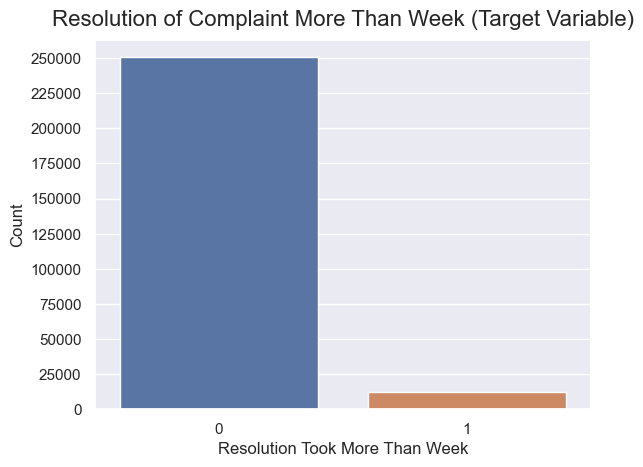

In [9]:
# Visualize target variable
sns.countplot(data, x="resolution_in_wk", hue="resolution_in_wk", legend=False)
plt.title("Resolution of Complaint More Than Week (Target Variable)", fontsize=16, pad=10)
plt.xlabel("Resolution Took More Than Week")
plt.ylabel("Count")
plt.yticks(np.arange(0, 260000, 25000))
plt.show()

#### Resolution time in days
The resolution time (in days) represents the difference between complaint creation and closure.

Analyzing this variable helps identify:

• typical service response timelines  
• potential outliers or data errors  
• cases where complaints appear to close before they were created

Records with negative resolution times likely indicate data entry issues and are removed to maintain data integrity.

In [10]:
data["resolution_time_days"].describe().round(2)

count    263110.00
mean          1.40
std           2.89
min          -6.00
25%           0.03
50%           0.16
75%           1.51
max          28.03
Name: resolution_time_days, dtype: float64

In [11]:
# Determine the number of rows with a negative "resolution_time_days"
data[data["resolution_time_days"] < 0].shape[0]

33

In [12]:
# Remove rows with a negative "resolution_time_days"
data = data[data["resolution_time_days"] >= 0].copy()

In [13]:
# Check counts
data.shape

(263077, 14)

In [14]:
# Confirm there are no longer minimum values
data["resolution_time_days"].min()

0.0

#### Borough vs. resolution in a week
Complaint resolution timelines may vary across boroughs due to differences in:

• service request volume  
• agency workload distribution  
• population density  
• infrastructure conditions

Examining borough-level resolution rates helps determine whether geographic location influences service response efficiency.

In [15]:
# Percent of resolution in by borough
pd.crosstab(
    data["borough"],
    data["resolution_in_wk"],
    normalize="index"
).rename(columns={
    0:"No",
    1:"Yes"
}).rename_axis("Borough").round(2)

resolution_in_wk,No,Yes
Borough,,
bronx,0.94,0.06
brooklyn,0.95,0.05
manhattan,0.94,0.06
queens,0.97,0.03
staten_island,0.96,0.04


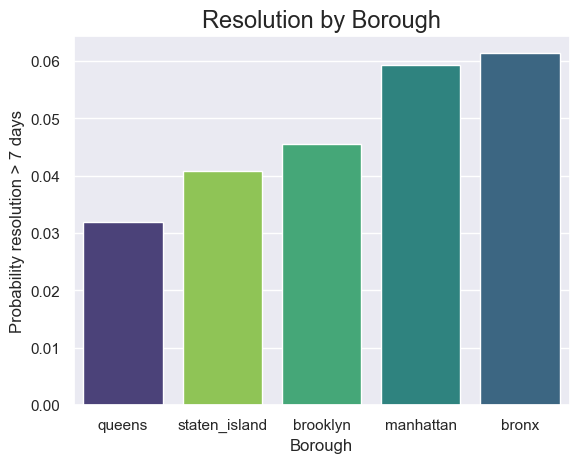

In [16]:
# Plot to show resolution by borough
sns.barplot(
    data,
    x="borough",
    y="resolution_in_wk", 
    hue="borough",
    palette="viridis",
    errorbar=None,
    order=data.groupby("borough")["resolution_in_wk"].mean().sort_values().index
)
plt.xlabel("Borough")
plt.ylabel("Probability resolution > 7 days")
plt.title("Resolution by Borough", fontsize=17)
plt.show()

#### Complaint type vs. resolution

Different complaint categories often require very different response processes. For example:

• noise complaints may be resolved quickly  
• infrastructure issues may require inspections or repairs  
• sanitation complaints may follow scheduled service routes

Understanding variation across complaint types helps determine how predictive this feature may be for modeling.

In [17]:
# Top 15 most frequent complaints
top_types = data["complaint_type"].value_counts().head(15).index
top_types

Index(['Illegal Parking', 'HEAT/HOT WATER', 'Noise - Residential',
       'Snow or Ice', 'Blocked Driveway', 'Traffic Signal Condition',
       'Noise - Street/Sidewalk', 'Street Condition', 'Dirty Condition',
       'Abandoned Vehicle', 'Noise - Commercial', 'Water System',
       'UNSANITARY CONDITION', 'Noise', 'PLUMBING'],
      dtype='object', name='complaint_type')

In [18]:
# Subset of data within top 15 complaint types
complaint_subset = data[data["complaint_type"].isin(top_types)]
complaint_subset.head()

,unique_key,agency,complaint_type,descriptor,incident_zip,borough,latitude,longitude,location_type,resolution_time_days,resolution_in_wk,complaint_hr,complaint_day,complaint_month
0,68336154,DOT,Street Condition,Pothole,11420,queens,40.678150,-73.831082,unknown,0.000000,0,1,0,3
1,68332725,NYPD,Noise - Residential,Banging/Pounding,11104,queens,40.742897,-73.925399,Residential Building/House,0.010498,0,1,0,3
2,68338535,NYPD,Blocked Driveway,Partial Access,11429,queens,40.715043,-73.737347,Street/Sidewalk,0.016169,0,1,0,3
3,68339824,NYPD,Noise - Residential,Banging/Pounding,10462,bronx,40.838182,-73.859103,Residential Building/House,0.018588,0,1,0,3
4,68335021,NYPD,Noise - Residential,Banging/Pounding,10462,bronx,40.838182,-73.859103,Residential Building/House,0.022338,0,1,0,3


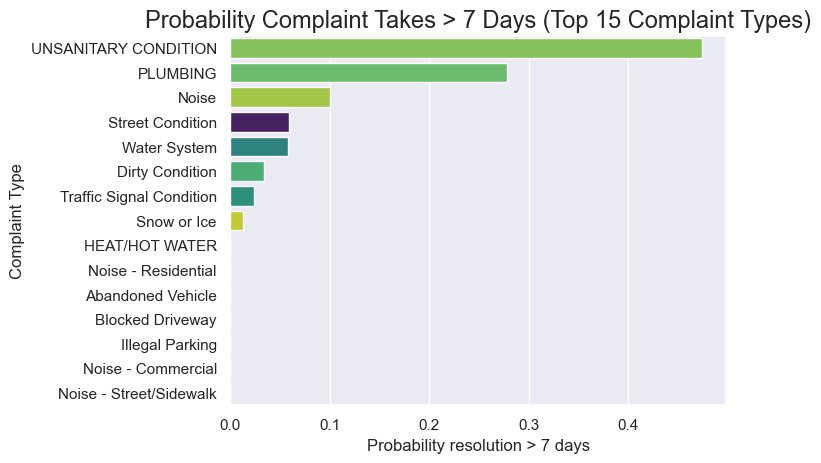

In [19]:
# Plot
sns.barplot(
    data=complaint_subset,
    x="resolution_in_wk",
    y="complaint_type",
    hue="complaint_type",
    palette="viridis",
    errorbar=None, 
    legend=False, 
    order = (complaint_subset.groupby("complaint_type")["resolution_in_wk"]\
             .mean().sort_values(ascending=False).index)
)

plt.xlabel("Probability resolution > 7 days")
plt.ylabel("Complaint Type")
plt.title("Probability Complaint Takes > 7 Days (Top 15 Complaint Types)", fontsize=17)
plt.show()

In [20]:
# Check sample sizes for each complaint
total_complaints = pd.DataFrame(complaint_subset["complaint_type"].value_counts(ascending=False))

total_complaints

,count
complaint_type,
Illegal Parking,47785
HEAT/HOT WATER,30329
Noise - Residential,29703
Snow or Ice,23161
Blocked Driveway,15965
Traffic Signal Condition,9293
Noise - Street/Sidewalk,7761
Street Condition,7139
Dirty Condition,6697


#### Complaints by borough
Complaint locations cluster by borough geography, confirming the spatial data is valid.

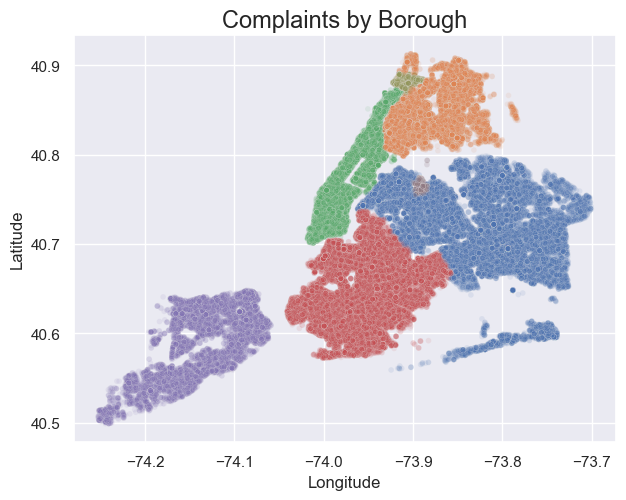

In [21]:
plt.figure(figsize=(7,7))
sns.scatterplot(
    data=data,
    y="latitude",
    x="longitude",
    alpha=0.1,
    hue="borough",
    legend=False,
    s=17
)
plt.title("Complaints by Borough", fontsize=17)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.gca().set_aspect("equal", adjustable="box")
plt.show()

#### Day of week and resolution probability
The day a complaint is filed appears to have minimal impact on whether it takes longer than one week to resolve.

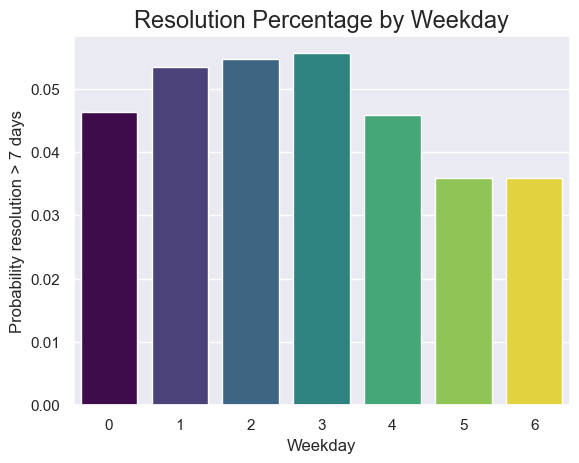

In [22]:
# Plot to show resolution by day of week
sns.barplot(
    data,
    x="complaint_day",
    y="resolution_in_wk", 
    hue="complaint_day",
    errorbar=None,
    palette="viridis",
    legend=False
)
plt.xlabel("Weekday")
plt.ylabel("Probability resolution > 7 days")
plt.title("Resolution Percentage by Weekday", fontsize=17)
plt.show()

#### Agency and Resolution Probability
Each complaint is routed to a specific city agency responsible for handling the issue.

Different agencies operate with varying:

• staffing levels  
• operational workflows  
• service priorities  

These differences may influence response times and therefore may be useful predictors for the model.

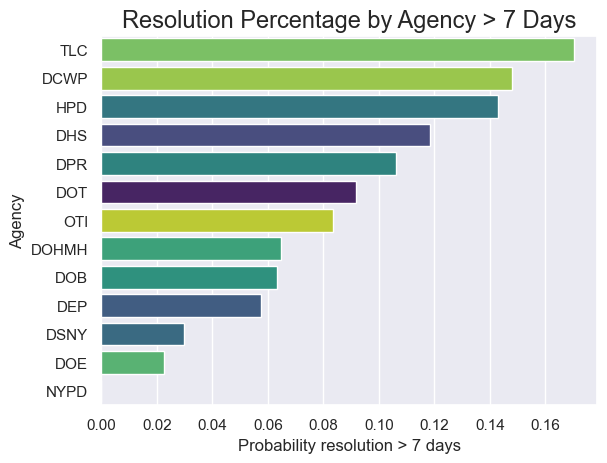

In [23]:
# Plot to show resolution by day of week
sns.barplot(
    data,
    y="agency",
    x="resolution_in_wk",
    errorbar=None,
    legend=False,
    hue="agency",
    palette="viridis",
    order = (data.groupby("agency")["resolution_in_wk"]\
             .mean().sort_values(ascending=False).index)
)
plt.ylabel("Agency")
plt.xlabel("Probability resolution > 7 days")
plt.title("Resolution Percentage by Agency > 7 Days", fontsize=17)
plt.show()

#### Export Data

In [24]:
data.to_parquet(DATA_DIR / "02_nyc_info_exploratory_analysis.parquet", index=False)